<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_09_Comparing_ML_Algorithms%2C_Automating_Workflows%2C_and_Enhancing_ML_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Comparing ML Algorithms, Automating Workflows, and Enhancing ML Performance


We have learned about **four linear machine
learning algorithms**: Linear Regression, Ridge Regression, LASSO Linear Regression and Elastic
Net Regression.

You also learned about **three nonlinear algorithms**:
k-Nearest Neighbors,
Classification and Regression Trees and Support Vector Machines.

Now we will discover
how **to design simple experiments to directly compare machine learning algorithms to each other
on your dataset**.

It is important to compare the performance of multiple different machine learning algorithms
consistently. In this chapter you will discover **how you can create a test harness to compare
multiple different machine learning algorithms in Python with scikit-learn**.

You can use **this
test harness as a template on your own machine learning problems and add more and different
algorithms to compare**. After completing this lesson you will know:
1. How to formulate an experiment to directly compare machine learning algorithms.
2. A reusable template for evaluating the performance of multiple algorithms on one dataset.
3. How to report and visualize the results when comparing algorithm performance.

### Choose The Best Machine Learning Model

When you work on a machine learning project, you often end up with **multiple good models
to choose from**.

Each model will have **different performance characteristics**. Using resampling
methods like **cross validation, you can get an estimate for how accurate each model may be on
unseen data**.

You need to be able to use **these estimates to choose one or two best models** from
the suite of models that you have created.

When you have a new dataset, it is a good idea to visualize the data using different techniques in order to look at the data from different perspectives. The same idea applies to model selection.
**You should use a number of different ways of looking at the estimated accuracy of your machine
learning algorithms in order to choose the one or two algorithm to finalize**.

A way to do this is
to use **visualization methods to show the average accuracy, variance and other properties of the
distribution of model accuracies**.

In the next section you will discover exactly how you can do
that in Python with scikit-learn.

### Compare Machine Learning Algorithms Consistently

The key to a **fair comparison of machine learning algorithms is ensuring that each algorithm is
evaluated in the same way on the same data**.

You can achieve this by forcing each algorithm to be evaluated on a consistent test harness. In the **example below six different classification algorithms are compared on a single dataset**:
- Logistic Regression.
- Linear Discriminant Analysis.
- k-Nearest Neighbors.
- Classification and Regression Trees.
- Naive Bayes.
- Support Vector Machines.

The dataset is the corrosion ship  problem.
- The problem has **two classes and eight numeric input variables of varying scales**.
- The **10-fold cross validation procedure** is used to evaluate each algorithm,
- **importantly configured with the same random seed** to ensure that the same splits to the training data are performed and that each algorithm is evaluated in precisely the same way.
- Each algorithm is given a **short name**, useful for summarizing results afterward.

---
**Load the file from a url to `content/data_sample`**

---

First of all we will load the file from a url and then save it in `content/data_sample`.

In [ ]:
!wget -O /content/sample_data/Corrosion_Detection_Ships.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Corrosion_Detection_Ships.csv

--2025-03-30 07:14:39--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Corrosion_Detection_Ships.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘/content/sample_data/Corrosion_Detection_Ships.csv’

/content/sample_dat 100%[===================>]  22.73K  --.-KB/s    in 0.001s  

2025-03-30 07:14:39 (32.5 MB/s) - ‘/content/sample_data/Corrosion_Detection_Ships.csv’ saved [23278/23278]



---
**Compare Algorithms**

---

LR: 0.772163 (0.049684)
LDA: 0.766969 (0.047966)
KNN: 0.710988 (0.050792)
CART: 0.698018 (0.048662)
NB: 0.759142 (0.038960)
SVM: 0.760458 (0.034712)


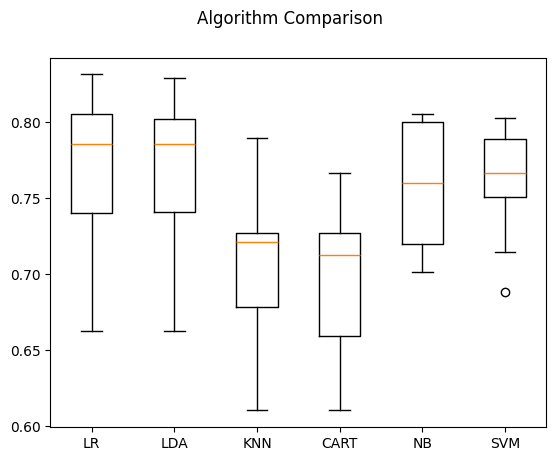

In [ ]:
from pandas import read_csv
from matplotlib import pyplot
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Cargar dataset
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:, 0:8]
Y = array[:, 8]

# Preparar modelos
models = []
models.append(('LR', LogisticRegression(max_iter=1000)))  # Aumentamos max_iter
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Evaluar modelos
results = []
names = []
scoring = 'accuracy'

for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Comparación de algoritmos
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()


Running the example provides a **list of each algorithm short name, the mean accuracy and
the standard deviation accuracy**.

The example also provides **a box and whisker plot showing the spread of the accuracy scores
across each cross validation fold for each algorithm**.

From these results, it would suggest that both **logistic regression and linear discriminant
analysis** are perhaps worthy of further study on this problem.

**But what if you need to prepare your data as part of the comparison process**. There are standard **workflows** in a machine learning project that can be automated. In Python
scikit-learn, **Pipelines** help to clearly define and automate these workflows. We are going to study:
1. How to use **pipelines to minimize data leakage**.
2. How to construct **a data preparation and modeling pipeline**.
3. How to construct **a feature extraction and modeling pipeline**.


## Automating Machine Learning Workflows

There are **standard workflows in applied machine learning**.

- Standard because they **overcome
common problems** like data leakage in your test harness.
- Python **scikit-learn provides a Pipeline
utility to help automate machine learning workflows**.
- Pipelines work by allowing for **a linear
sequence of data transforms to be chained together** culminating in a modeling process that can be evaluated.

**The goal is to ensure that all of the steps in the pipeline are constrained to the data available
for the evaluation**, such as the training dataset or each fold of the cross validation procedure.

- You can learn more about Pipelines in scikit-learn by reading the [Pipeline section](http://scikit-learn.org/stable/modules/classes.html#m) of the user
guide.
- You can also review the **API documentation** for the Pipeline and FeatureUnion classes
and the [`pipeline` module](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.pipeline).

## Data Preparation and Modeling Pipeline
**An easy trap to fall into in applied machine learning is leaking data from your training dataset
to your test dataset**.

**To avoid this trap you need a robust test harness with strong separation of training and testing**. This includes **data preparation**.


**Data preparation is one easy way to leak
knowledge of the whole training dataset to the algorithm**.
- For example, preparing your data
using **normalization or standardization on the entire _training dataset_ before learning would not
be a valid test** because the **training dataset would have been influenced by the _scale_** of the data in the test set.

- Pipelines help you prevent data leakage in your test harness by ensuring that data preparation
like **standardization is constrained to each fold of your cross validation procedure**.

The example below demonstrates this important data preparation and model evaluation workflow on the
Corrosion ships dataset.

The pipeline is defined with two steps:
  1. Standardize the data.
  2. Learn a Linear Discriminant Analysis model.

The pipeline is then evaluated using 10-fold cross validation.

---
**Create a pipeline that standardizes the data then creates a model**

---

In [ ]:
# Create a pipeline that standardizes the data then creates a model
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
# create pipeline
estimators = []
estimators.append(('standardize', StandardScaler()))
estimators.append(('lda', LinearDiscriminantAnalysis()))
model = Pipeline(estimators)
# evaluate pipeline
kfold = KFold(n_splits=10, random_state=7,shuffle=True)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7669685577580315


**Notice:**

1. How we create a Python list of steps that are provided to the Pipeline for process
the data.
2. Also notice how the Pipeline itself is treated like an estimator and is evaluated in its
entirety by the k-fold cross validation procedure.

Running the example provides a summary of
accuracy of the setup on the dataset.

## Feature Extraction and Modeling Pipeline

**Feature extraction is another procedure that is susceptible to data leakage**.

Like data preparation,
feature extraction procedures **must be restricted to the data in your training dataset**. The
pipeline provides a handy tool called the `FeatureUnion` which **allows the results of multiple
feature selection and extraction procedures to be combined into a larger dataset on which a
model can be trained**.

Importantly, all the feature extraction and the feature union occurs
within each fold of the cross validation procedure. The example below demonstrates the pipeline
defined with four steps:

1. Feature Extraction with Principal Component Analysis (3 features).
2. Feature Extraction with Statistical Selection (6 features).
3. Feature Union.
4. Learn a Logistic Regression Model.

The pipeline is then evaluated using 10-fold cross validation.

---
**Create a pipeline that extracts features from the data then creates a model**

---

In [ ]:
# Create a pipeline that extracts features from the data then creates a model
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
# create feature union
features = []
features.append(('pca', PCA(n_components=3)))
features.append(('select_best', SelectKBest(k=6)))
feature_union = FeatureUnion(features)
# create pipeline
estimators = []
estimators.append(('feature_union', feature_union))
estimators.append(('logistic', LogisticRegression(max_iter=500)))
model = Pipeline(estimators)
# evaluate pipeline
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7721633629528366


**Notice:**
1. how the `Feature Union` is it’s own Pipeline that in turn is a single step in the final
Pipeline used to feed Logistic Regression.
2. This might get you thinking about how you can start
embedding pipelines within pipelines.

Running the example provides a summary of accuracy of
the setup on the dataset.

## Combine Models Into Ensemble Predictions

We have learned how to use Pipelines in two important
use cases:
- Data preparation and modeling constrained to each fold of the cross validation procedure.
- Feature extraction and feature union constrained to each fold of the cross validation
procedure.

Now, we are going to learn **how ensembles can give us a boost in accuracy on our dataset**.

We will discover
how you can create some of the most powerful types of ensembles in Python using scikit-learn.
This lesson will step you through **Boosting, Bagging and Majority Voting and show you how you
can continue to ratchet up the accuracy of the models on your own datasets**.

After completing
this lesson you will know:
1. How to use **bagging ensemble methods** such as bagged decision trees, random forest and
extra trees.
2. How to use **boosting ensemble methods** such as **AdaBoost and stochastic gradient boosting**.
3. How to use **voting ensemble methods** to combine the predictions from multiple algorithms.

The three most popular methods for combining the predictions from different models are:
- **Bagging**. Building multiple models (typically of the _same type_) from **different subsamples**
of the training dataset.
- **Boosting**. Building multiple models (typically of the _same type_) each of which learns to
**fix the prediction errors of a prior model** in the sequence of models.
- **Voting**. Building multiple models (typically of _differing types_) and simple statistics (like
calculating the mean) are used to **combine predictions**.

This assumes you are generally familiar with machine learning algorithms and ensemble
methods and **will not go into the details of how the algorithms work or their parameters**.

The Corrosion ship dataset is used to demonstrate each algorithm. Each
ensemble algorithm is demonstrated using 10-fold cross validation and the classification accuracy
performance metric.

## Bagging Algorithms
Bootstrap Aggregation (or Bagging) involves **taking multiple samples from your training dataset
(with replacement)** and training a model for each sample. The final **output prediction is averaged
across the predictions of all of the sub-models**.

The three bagging models covered in this section
are as follows:
- Bagged Decision Trees.
- Random Forest.
- Extra Trees.

### Bagged Decision Trees

Bagging performs best with algorithms that have **high variance**. A popular example are
**decision trees**, often constructed without pruning.

In the example below is an example
of using the `BaggingClassifier` with the Classification and Regression Trees algorithm
([`DecisionTreeClassifier`](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) ).

A total of 100 trees are created.

---
**Bagged Decision Trees for Classification**

---

In [ ]:
# Bagged Decision Trees for Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
cart = DecisionTreeClassifier()
num_trees = 100
model = BaggingClassifier(estimator=cart, n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7578263841421736


Running the example, we get a robust estimate of model accuracy.

### Random Forest

**Random Forests is an extension of bagged decision trees**.

**Samples of the training dataset are
taken with replacement, but the trees are constructed in a way that reduces the correlation
between individual classifiers**.

Specifically, rather than greedily choosing the best split point in
the construction of each tree, **only a random subset of features are considered for each split**.

You can construct a Random Forest model for classification using the [`RandomForestClassifier`
class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) .

The example below demonstrates using Random Forest for classification with 100 trees
and split points chosen from a random selection of 3 features.

---
**Random Forest Classification**

---

In [ ]:
# Random Forest Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
num_trees = 100
max_features = 3
kfold = KFold(n_splits=10, random_state=7,shuffle=True)
model = RandomForestClassifier(n_estimators=num_trees, max_features=max_features)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7721804511278195


Running the example provides a mean estimate of classification accuracy.

### Extra Trees

Extra Trees are another modification of bagging where random trees are constructed from
samples of the training dataset. You can construct an Extra Trees model for classification using
the [`ExtraTreesClassifier class`](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html) . The example below provides a demonstration of extra trees
with the number of trees set to 100 and splits chosen from 7 random features.

---
**Extra Trees Classification**

---

In [ ]:
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
num_trees = 100
max_features = 7
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
model = ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7708817498291183


Running the example provides a mean estimate of classification accuracy.

## Boosting Algorithms
Boosting ensemble algorithms creates a sequence of models that attempt to correct the mistakes
of the models before them in the sequence. Once created, the models make predictions which
may be weighted by their demonstrated accuracy and the results are combined to create a final
output prediction. The two most common boosting ensemble machine learning algorithms are:
- AdaBoost.
- Stochastic Gradient Boosting.

### AdaBoost
AdaBoost was perhaps the first successful boosting ensemble algorithm. It generally works
by weighting instances in the dataset by how easy or difficult they are to classify, allowing
the algorithm to pay or less attention to them in the construction of subsequent models. You
can construct an AdaBoost model for classification using the [`AdaBoostClassifier` class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) . The
example below demonstrates the construction of 30 decision trees in sequence using the AdaBoost
algorithm.

---
**AdaBoost Classification**

---

In [ ]:
# AdaBoost Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
num_trees = 30
seed=7
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7552460697197538


Running the example provides a mean estimate of classification accuracy.

### Stochastic Gradient Boosting
Stochastic Gradient Boosting (also called Gradient Boosting Machines) are **one of the most
sophisticated ensemble techniques**.

It is also a technique that is proving to be **perhaps one of
the best techniques available for improving performance via ensembles**.
You can construct a
Gradient Boosting model for classification using the [`GradientBoostingClassifier` class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) .

The
example below demonstrates Stochastic Gradient Boosting for classification with 100 trees.

---
**Stochastic Gradient Boosting Classification**

---

In [ ]:
# Stochastic Gradient Boosting Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
seed = 7
num_trees = 100
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7578947368421053


Running the example provides a mean estimate of classification accuracy.

## Voting Ensemble

Voting is one of the **simplest ways of combining the predictions from multiple machine learning
algorithms**.

It works by first **creating two or more standalone models from your training dataset**.

A **Voting Classifier can then be used to wrap your models and average the predictions of the
sub-models when asked to make predictions for new data**. The predictions of the sub-models **can
be weighted**, but specifying the weights for classifiers manually or even heuristically **is difficult**.

More advanced methods **can learn how to best weight the predictions from sub-models**, but this
is called **stacking (stacked aggregation) and is currently not provided in scikit-learn**.

You can create a voting ensemble model for classification using the [`VotingClassifier`
class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) .

The code below provides an example of combining the predictions of logistic regression,
classification and regression trees and support vector machines together for a classification
problem.

---
**Voting Ensemble for Classification**

---

In [ ]:
# Voting Ensemble for Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
# create the sub models
estimators = []
model1 = LogisticRegression(max_iter=500)
estimators.append(('logistic', model1))
model2 = DecisionTreeClassifier()
estimators.append(('cart', model2))
model3 = SVC()
estimators.append(('svm', model3))
# create the ensemble model
ensemble = VotingClassifier(estimators)
results = cross_val_score(ensemble, X, Y, cv=kfold)
print(results.mean())

0.7708646616541355


Running the example provides a mean estimate of classification accuracy.